
ARIMA, which is a very successful statistical linear method to forecast time series data. However, in many cases, time series data have non-linearity, which cannot be mapped by linear models. In such cases, the ability of SVM to consider non-linearity in the data for regression tasks makes SVR successful in time series forecasting.



In [1]:
import sys
sys.path.append('.')

In [2]:
import os
import warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import datetime as dt
import math


from sklearn.svm import SVR
from sklearn.preprocessing import MinMaxScaler 
from common.utils import load_data, mape

Load the data

In [3]:
energy = load_data('.')[['load']]

e:\bryan - Copy\4.2\dataScience\ML\Timeseries\common\utils.py:16: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  energy = energy.reindex(pd.date_range(min(energy['timestamp']),


Plot all the available energy data from January 2012 to December 2014

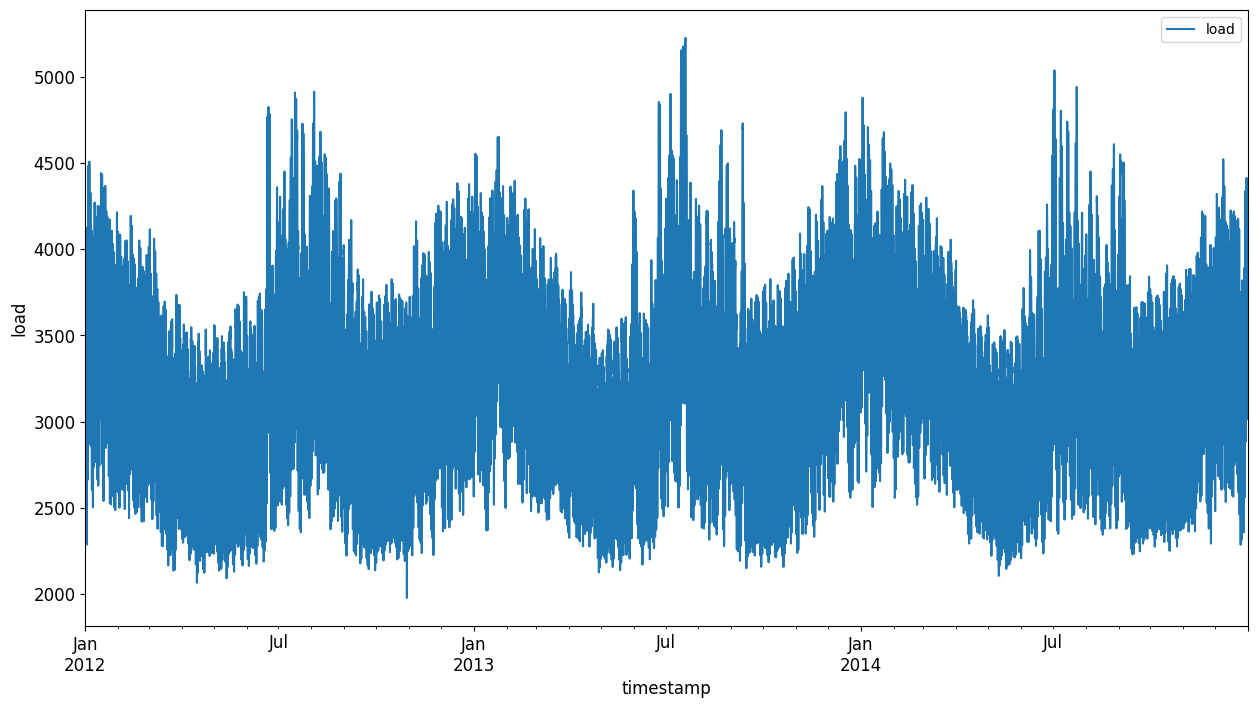

In [4]:
energy.plot(y='load',subplots=True, figsize=(15, 8), fontsize=12)
plt.xlabel('timestamp', fontsize=12)
plt.ylabel('load', fontsize=12)
plt.show()

Create training and testing datasets
Now your data is loaded, so you can separate it into train and test sets.

Allocate a two-month period from September 1 to October 31, 2014 to the training set. The test set will include the two-month period of November 1 to December 31, 2014:

In [9]:
train_start_dt= '2014-11-01 00:00:00'
test_start_dt = '2014-12-30 00:00:00'


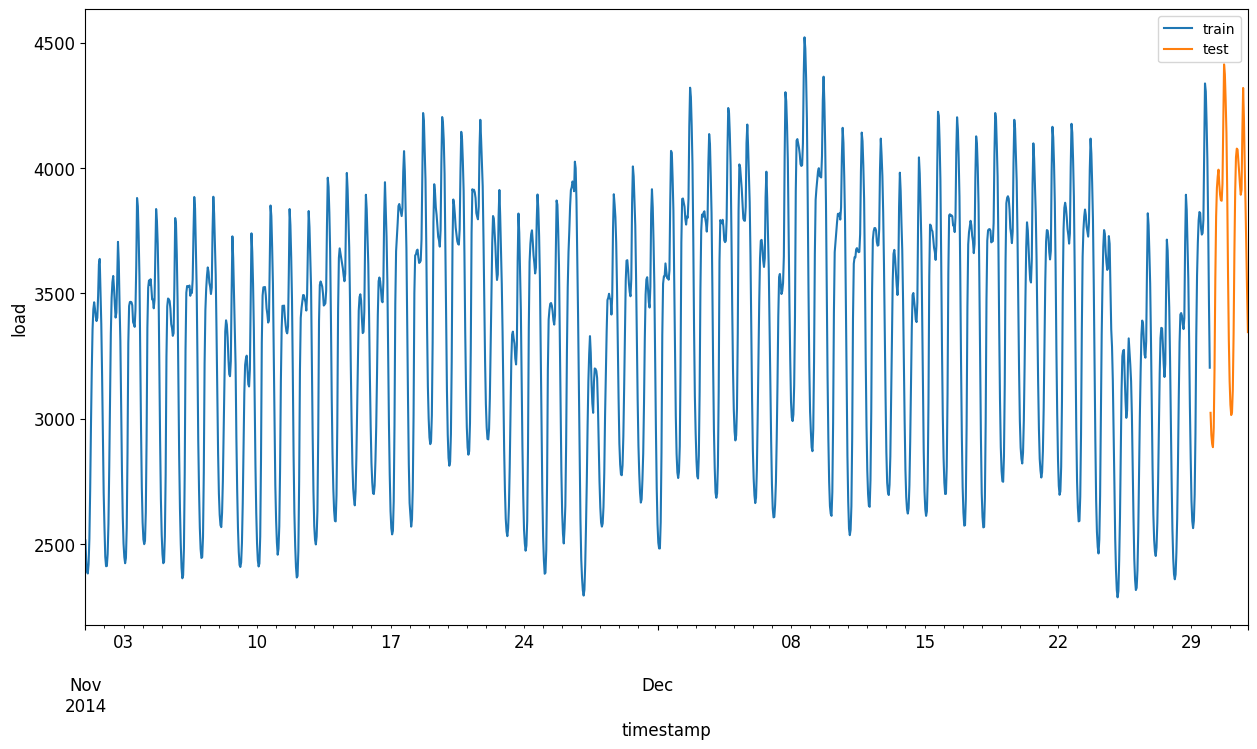

In [10]:
energy[(energy.index < test_start_dt) & (energy.index >= train_start_dt)][['load']].rename(columns={'load':'train'}) \
    .join(energy[test_start_dt:][['load']].rename(columns={'load':'test'}), how='outer') \
    .plot(y=['train', 'test'], figsize=(15, 8), fontsize=12)
plt.xlabel('timestamp', fontsize=12)
plt.ylabel('load', fontsize=12)
plt.show()

Prepare the data for training


Now, you need to prepare the data for training by performing filtering and scaling of your data. Filter your dataset to only include the time periods and columns you need, and scaling to ensure the data is projected in the interval 0,1.


Filter the original dataset to include only the aforementioned time periods per set and only including the needed column 'load' plus the date: 2

In [11]:
train = energy.copy()[(energy.index >= train_start_dt) & (energy.index < test_start_dt)][['load']]
test = energy.copy()[(energy.index >= test_start_dt)][['load']]


print('Training data shape: ', train.shape)
print('Test data shape: ', test.shape)

Training data shape:  (1416, 1)
Test data shape:  (48, 1)


Scale the training data to be in the range (0, 1):

In [12]:
scaler = MinMaxScaler()
train['load'] = scaler.fit_transform(train)

Now, you scale the testing data

In [13]:
test['load'] = scaler.transform(test)

Create data with time-steps 1


For the SVR, you transform the input data to be of the form [batch, timesteps]. So, you reshape the existing train_data and test_data such that there is a new dimension which refers to the timesteps.

In [14]:
#conerting to numpy arrays
train_data = train.values
test_data = test.values

For this example, we take timesteps = 5. So, the inputs to the model are the data for the first 4 timesteps, and the output will be the data for the 5th timestep.

In [17]:
timesteps = 5

Converting training data to 2D tensor using nested list comprehension:

In [19]:
train_data_timesteps=np.array([[j for j in train_data[i:i+timesteps]] for i in range(0,len(train_data) - timesteps+1)])[:,:,0]
train_data_timesteps.shape

(1412, 5)

Converting testing data to 2D tensor:

In [20]:
test_data_timesteps = np.array([[j for j in test_data[i:i+timesteps]] for i in range(0,len(test_data)-timesteps+1)])[:,:,0]
test_data_timesteps.shape

(44, 5)

Selecting inputs and outputs from training and testing data:

In [21]:
x_train, y_train = train_data_timesteps[:,:timesteps-1], train_data_timesteps[:, [timesteps-1]]
x_test, y_test = test_data_timesteps[:,:timesteps-1], test_data_timesteps[:,[timesteps-1]]

print(x_train.shape, y_train.shape)
print(x_test.shape, y_test.shape)

(1412, 4) (1412, 1)
(44, 4) (44, 1)


Now we create an SVR model. Here we use the RBF kernel, and set the hyperparameters gamma, C and epsilon as 0.5, 10 and 0.05 respectively.

In [26]:
model = SVR(kernel='rbf', gamma=0.5 , C=10, epsilon=0.05)

Fit the model on training data

In [27]:
model.fit(x_train, y_train[:,0])

,kernel,'rbf'
,degree,3
,gamma,0.5
,coef0,0.0
,tol,0.001
,C,10
,epsilon,0.05
,shrinking,True
,cache_size,200
,verbose,False
,max_iter,-1


Make model predictions

In [28]:
y_train_pred = model.predict(x_train).reshape(-1,1)
y_test_pred = model.predict(x_test).reshape(-1,1)

print(y_train_pred.shape, y_test_pred.shape)

(1412, 1) (44, 1)


Evaluate your model


For evaluation, first scale back the data to original scale. Then, to check the performance plot the original and predicted time series plot, and also print the MAPE result.

Scale the predicted and original output:

In [29]:
#scaling the predictions
y_train_pred = scaler.inverse_transform(y_train_pred)
y_test_pred = scaler.inverse_transform(y_test_pred)

print(len(y_train_pred), len(y_test_pred))

1412 44


In [30]:
#scaling the original values
y_train = scaler.inverse_transform(y_train)
y_test = scaler.inverse_transform(y_test)

print(len(y_train), len(y_test))

1412 44


Check model performance on training and testing data 


We extract the timestamps from the dataset to show in the x-axis of our plot. Note that we are using the first timesteps-1 values as out input for the first output, so the timestamps for the output will start after that.

In [32]:
train_timesteps = energy[(energy.index < test_start_dt) & (energy.index >= train_start_dt)].index[timesteps -1:]
test_timesteps = energy[test_start_dt:].index[timesteps-1:]

print(len(train_timesteps),len(test_timesteps))

1412 44


Plot the predictions for training data:

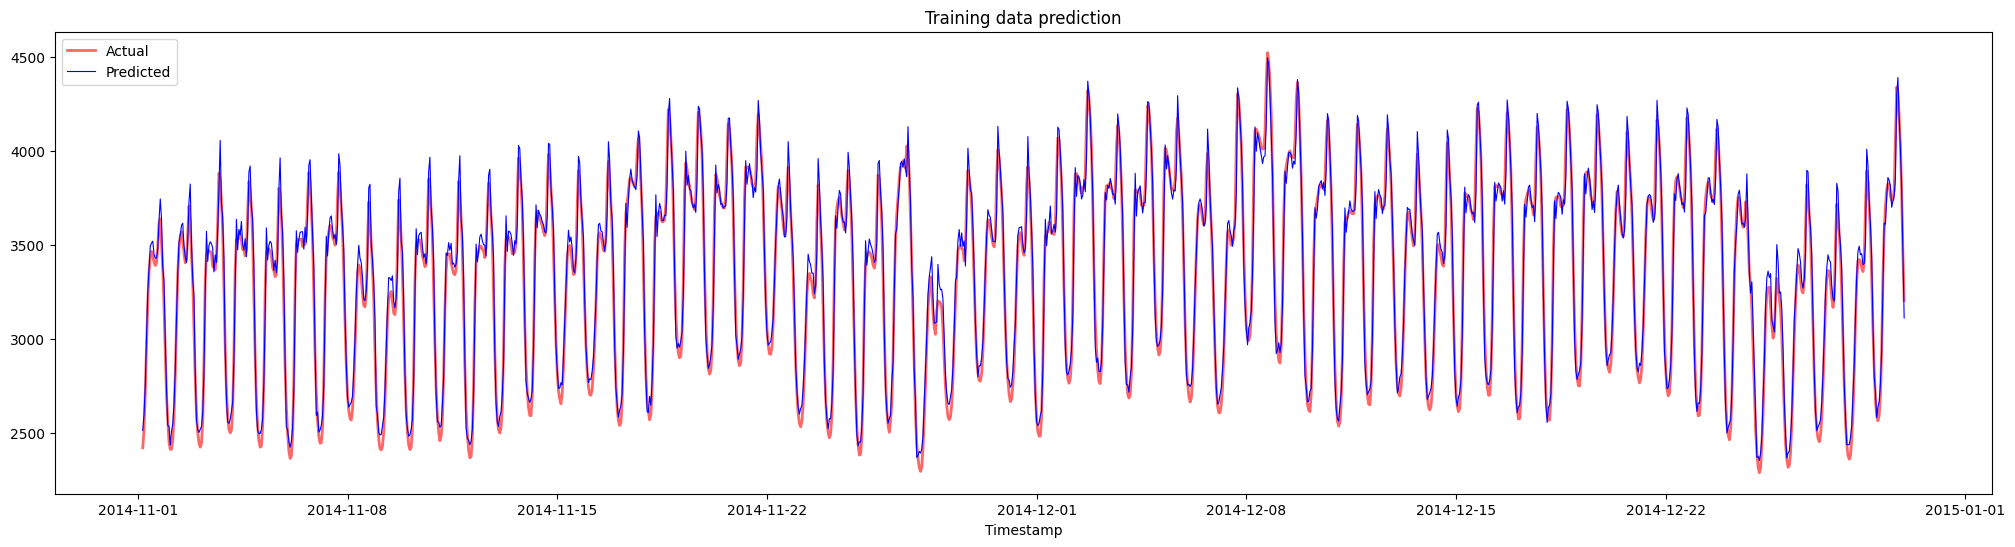

In [34]:
plt.figure(figsize=(25,6))
plt.plot(train_timesteps, y_train, color = 'red', linewidth=2.0, alpha = 0.6)
plt.plot(train_timesteps, y_train_pred, color = 'blue', linewidth=0.8)
plt.legend(['Actual','Predicted'])
plt.xlabel('Timestamp')
plt.title("Training data prediction")
plt.show()

Print MAPE for training data

In [35]:
print('MAPE for training data: ', mape(y_train_pred, y_train) *100, '%')

MAPE for training data:  1.7195710200875551 %


Plot the predictions for testing data


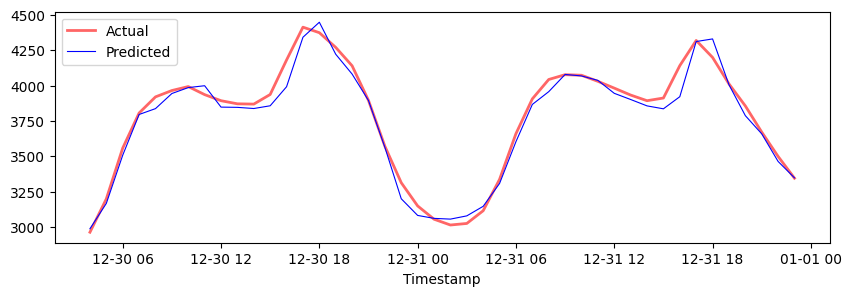

In [36]:
plt.figure(figsize=(10,3))
plt.plot(test_timesteps, y_test, color = 'red', linewidth=2.0, alpha = 0.6)
plt.plot(test_timesteps, y_test_pred, color = 'blue', linewidth=0.8)
plt.legend(['Actual','Predicted'])
plt.xlabel('Timestamp')
plt.show()

Print MAPE for testing data

In [38]:
print('MAPE for testing data: ' ,mape(y_test_pred, y_test)*100, '%')

MAPE for testing data:  1.2623790187854018 %


Check model performance on full dataset

In [39]:
#Extracting load values as numpy array
data = energy.copy().values

#scaling
data = scaler.transform(data)

#Transforming to 2D tensor as per model input requiremnets
data_timesteps=np.array([[j for j in data[i:i+timesteps]] for i in range(0,len(data)-timesteps+1)])[:,:,0]
print("Tensor shape: ", data_timesteps.shape)

#selecting inputs and outputs from data
X, Y = data_timesteps[:,:timesteps-1],data_timesteps[:,[timesteps-1]]
print("X shape: " ,X.shape, "\nY shape: ", Y.shape)

e:\bryan - Copy\4.2\dataScience\datascience_env\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


Tensor shape:  (26300, 5)
X shape:  (26300, 4) 
Y shape:  (26300, 1)


In [40]:
#Make model predictions
Y_pred = model.predict(X).reshape(-1,1)

#inverse scale and reshape
Y_pred = scaler.inverse_transform(Y_pred)
Y = scaler.inverse_transform(Y)

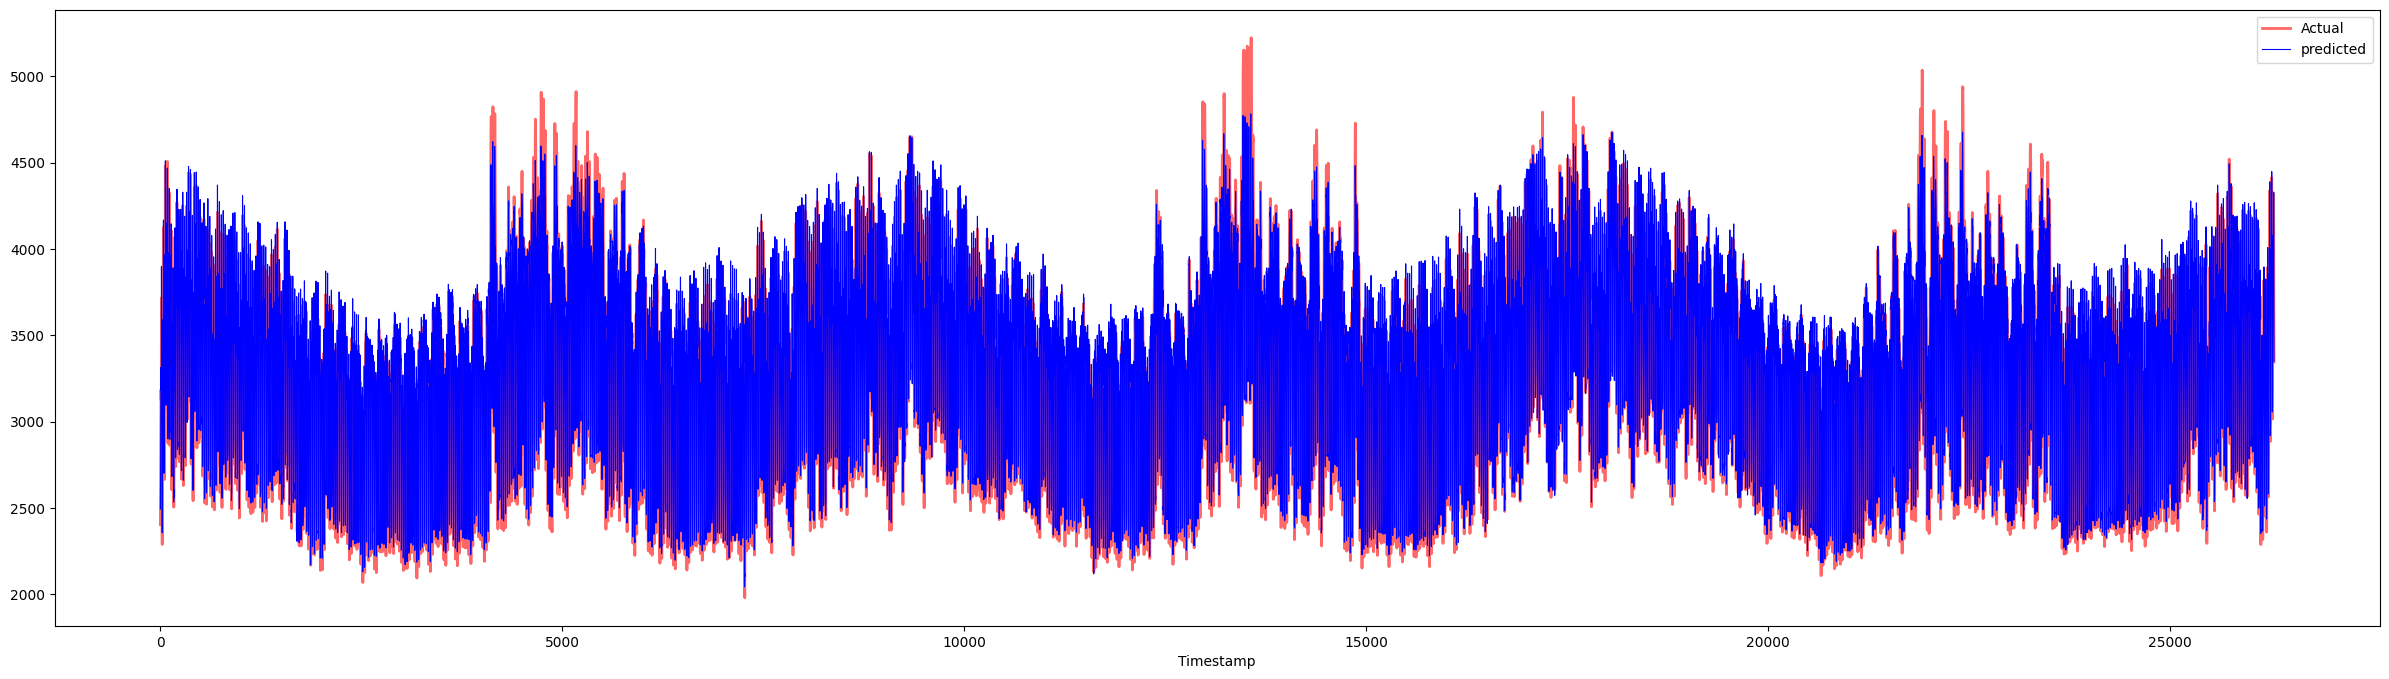

In [41]:
plt.figure(figsize=(30,8))
plt.plot(Y, color = 'red', linewidth=2.0, alpha = 0.6)
plt.plot(Y_pred, color = 'blue' , linewidth=0.8)
plt.legend(["Actual",'predicted'])
plt.xlabel('Timestamp')
plt.show()

In [42]:
print("MAPE: ", mape(Y_pred, Y)*100, '%')

MAPE:  2.0572089029888656 %
